In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir('/content/gdrive/My Drive/')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# U-Net segmentation — PyTorch version
This notebook contains a semantic segmentation example using U-Net architecture

Ronneberger, O., Fischer, P., & Brox, T. (2015, October). U-net: Convolutional networks for biomedical image segmentation. In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Springer, Cham.

https://link.springer.com/content/pdf/10.1007/978-3-319-24574-4_28.pdf

 Architecture U-Net modulaire, pertes de segmentation, et génération de la base synthétique.

Voir le dossier `dl_tools_torch/` :
- `random_image_generator.py` : image generation ("dead leaves")
- `dataset_torch.py` : `DeadLeavesSegDataset` + `make_dataloader`
- `modular_unet_torch.py` : `ModularUNet`
- `losses_torch.py` : dice/jaccard/focal/tversky/lovasz
- `eval_torch.py` : matrice de confusion, IoU, precision/recall
- `tools_torch.py` : training loop, visualisation


In [2]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import torch

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

from dl_tools_torch.random_image_generator import (
    AdditiveGaussianNoise, ROG_rings, RandomPosGenUniform, RandomIntGenUniform,
)
from dl_tools_torch.dataset_torch import make_dataloader, make_fixed_dataloader
from dl_tools_torch.modular_unet_torch import ModularUNet, AttentionModularUNet
from dl_tools_torch import tools_torch, eval_torch
from parameters_torch import Parameters
sys.path.insert(1, '/content/gdrive/MyDrive/dl_tools_torch')
from tools_torch import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


## Base synthétique (dead-leaves) via DataLoader
# Working database (using a data generator)

We are working with a synthetic database, which allows us to generate an unlimited amount of data along with their corresponding ground truth, without any annotation effort.

We create a multi-class database:
<ul>
    <li>Class 1, representing large rings with a reasonable contrast</li>
    <li>Class 2, smaller rings with lower contrast</li>
</ul>


Since class 2 contains fewer rings in each image and moreover those rings are smaller our database is unballanced. Consequently, segmenting class 2 is more challenging compared to class 1. The reason for that is that the majority class has a greater influence on the optimization process.



We propose the following parameters for the DB:

### majority class (large contrasted rings)

nb_obj_l = 1 # 1 to 3 objects per image

nb_obj_h = 3

r1_ring_l = 8 # radius from 8 to 14

r1_ring_h = 14

grey_l = 50 # grey level from 50 to 200

grey_h = 200

### minority class (smaller rings and less contrasted)

nb2_obj_l = 1 # 1 to 2 objects per image

nb2_obj_h = 2

r2_ring_l = 3 # radius from 3 to 6

r2_ring_h = 6

grey2_l = 70 # grey level from 70 to 150

grey2_h = 150
`

Deux types de `Dataset` sont fournis :
- `DeadLeavesSegDataset` (→ `make_dataloader`) : **new** sample each `__getitem__`.
- `FixedDeadLeavesSegDataset` (→ `make_fixed_dataloader`) : generates `n_samples`
  **only once**, with an optional `seed. **Used for  validation and test**, so that
  `val_loss` are comparable across epochs and runs.


In [3]:
NUM_CLASSES = len(np.unique([0] + [1, 2]))  # fond=0, grand anneau=1, petit anneau=2 -> 3
def build_rog_list(myP):
    """Liste des générateurs d'objets aléatoires (classe majoritaire + minoritaire)."""
    l_rog = [
        # classe majoritaire
        ROG_rings(
            RandomIntGenUniform(myP.nb_obj_l, myP.nb_obj_h),
            RandomPosGenUniform(myP.img_rows, myP.img_cols),
            RandomIntGenUniform(myP.r1_ring_l, myP.r1_ring_h),
            RandomIntGenUniform(myP.grey_l, myP.grey_h),
            gt=1,
            rad_ratio=0.5),
        # classe minoritaire
        ROG_rings(
            RandomIntGenUniform(myP.nb2_obj_l, myP.nb2_obj_h),
            RandomPosGenUniform(myP.img_rows, myP.img_cols),
            RandomIntGenUniform(myP.r2_ring_l, myP.r2_ring_h),
            RandomIntGenUniform(myP.grey2_l, myP.grey2_h),
            gt=2,
            rad_ratio=0.5),
    ]
    return l_rog


def make_loaders(myP, num_classes=None, val_test_seed=42):
    """Construit les DataLoaders train/val/test à partir des paramètres myP.

    Le train set est régénéré à chaque epoch (données illimitées). Val et
    test sont générés UNE FOIS avec `val_test_seed` (val_seed != test_seed
    pour que les deux ensembles ne se recouvrent pas) : ils restent
    identiques d'une epoch à l'autre et d'une exécution à l'autre tant que
    le seed ne change pas, ce qui permet de comparer plusieurs runs entre eux.
    """
    l_rog = build_rog_list(myP)
    noise = AdditiveGaussianNoise(myP.gauss_n_std)

    common = dict(
        x_size=myP.img_rows, y_size=myP.img_cols, rog_list=l_rog, noise=noise,
        background_val=0, norm=myP.norm, num_classes=num_classes,
    )
    train_loader = make_dataloader(length=myP.nb_train_samples, batch_size=myP.batch_size,
                                    shuffle=True, **common)
    val_loader = make_fixed_dataloader(n_samples=myP.nb_val_samples, batch_size=myP.batch_size,
                                        shuffle=False, seed=val_test_seed, **common)
    test_loader = make_fixed_dataloader(n_samples=myP.nb_test_samples, batch_size=myP.batch_size,
                                         shuffle=False, seed=val_test_seed + 1, **common)
    return train_loader, val_loader, test_loader


myP = Parameters(MODEL="modular_u_net", batch_size=128, opt_name="rmsprop")
train_loader, val_loader, test_loader = make_loaders(myP,num_classes=NUM_CLASSES)

# un batch pour visualisation
X_batch, Y_batch = next(iter(train_loader))
print("X:", X_batch.shape, X_batch.dtype, "Y:", Y_batch.shape, Y_batch.dtype)


X: torch.Size([128, 1, 32, 32]) torch.float32 Y: torch.Size([128, 3, 32, 32]) torch.float32


Two images from the training dataset (original image and its corresponding ground truth) :

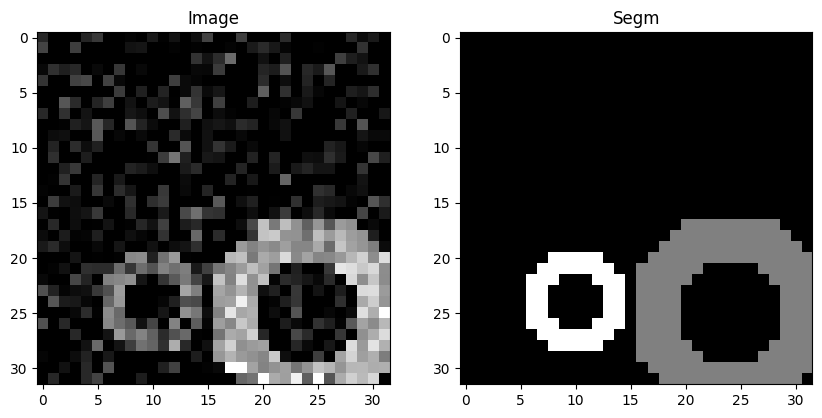

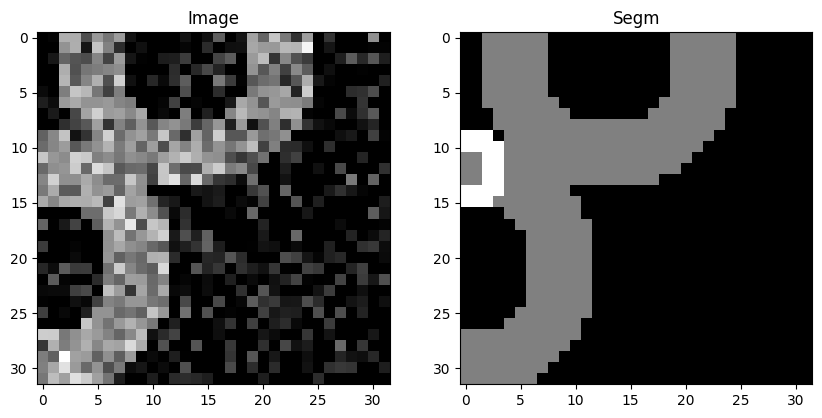

<Figure size 1000x800 with 0 Axes>

In [4]:
tools_torch.visualize_batch(2, X_batch.numpy(), Y_batch.numpy(), show=True)


In [5]:
# distribution des labels dans le batch
vals, counts = np.unique(Y_batch.numpy(), return_counts=True)
print(dict(zip(vals.tolist(), (counts / counts.sum()).round(4).tolist())))


{0.0: 0.6667, 1.0: 0.3333}


## Entraînement

In [7]:
myP = Parameters(MODEL="modular_u_net", batch_size=128, opt_name="rmsprop")
myP.showFlag = True
myP.nb_filters = 2
myP.nb_epoch = 2
myP.patience = 3
myP.lossF = "jac2"       # ["jac2", "cce", "focal", "mse"]
myP.opt_name = "rmsprop"  # ["sgd", "adam", "rmsprop", ...]
myP.lr = 0.00005# jac2
myP.baseName = "modular_unet_run"

myP.baseName = '-'.join(map(str,myP.classList))+"_E"+str(myP.nb_epoch)+"_F"+str(myP.nb_filters)+myP.lossF+"_"+myP.opt_name+"_"+str(myP.lr)
time_str = get_time_string()
myP.time_str = time_str
myP.dirRes=os.path.join("results",time_str+"_"+myP.baseName)
if(not os.path.exists(myP.dirRes)): os.makedirs(myP.dirRes)

train_loader, val_loader, test_loader = make_loaders(myP,num_classes=NUM_CLASSES)

model = ModularUNet(
    in_channels=myP.img_channels,
    nb_levels=myP.nb_levels,
    nb_filters_0=myP.nb_filters,
    output_channels=NUM_CLASSES,   # fond + 2 classes, une sortie softmax par classe
    output_activation="softmax",
    sigma_noise=myP.sigma_noise,
    drop=myP.drop,
    skip=myP.skip,
    res=myP.res,
    conv_sampling=myP.conv_sampling,
    batch_norm=myP.batch_norm,
)



In [8]:
#import pdb
#for x, y in train_loader:
#  x, y = x.to(device), y.to(device)
#  y_pred = model(x)
#  break

In [9]:
history = tools_torch.train_model(model, train_loader, val_loader, myP, device=device)

best_val = min(history["val_loss"])
print("Best validation loss: %.5f at epoch %d" % (best_val, int(np.argmin(history["val_loss"]))))

tools_torch.plot_learning_curves(
    history,
    os.path.join(myP.dirRes, myP.baseName + "_learningCurves.png"),
    show=myP.showFlag,
)


Epoch 1/2 - loss: 0.17491 - val_loss: 0.14707
Epoch 2/2 - loss: 0.15833 - val_loss: 0.15359
Best validation loss: 0.14707 at epoch 0


<Figure size 1000x800 with 0 Axes>

## Prédiction et évaluation
Le modèle produit `NUM_CLASSES` canaux softmax (un par classe,
fond inclus). On récupère la carte de labels prédite par `argmax` sur l'axe
des canaux, et on calcule précision/rappel/F-mesure/IoU **par classe**
(fond, grand anneau, petit anneau) via `eval_torch.evaluate`.

In [10]:
X_val, Y_val = tools_torch.collect_dataset(val_loader)   # jeu de validation ENTIER (fixe, seed=42)
Y_pred = tools_torch.predict(model, val_loader, device=device)  # prédiction sur ce même ensemble entier
print("X_val:", X_val.shape, "Y_val:", Y_val.shape, "Y_pred:", Y_pred.shape)

# Y_val et Y_pred sont one-hot / softmax (N, NUM_CLASSES, H, W) -> cartes de labels (N, H, W)
Y_val_lab = np.argmax(Y_val, axis=1)
Y_pred_lab = np.argmax(Y_pred, axis=1)

precision, recall, fmean, iou, miou = eval_torch.evaluate(
    Y_pred_lab, Y_val_lab, num_classes=NUM_CLASSES,
    dir_res=myP.dirRes, base_name=myP.baseName, show=myP.showFlag,
)
print("classes: [fond, grand anneau, petit anneau]")
print("precision:", precision)
print("recall:   ", recall)
print("F-mesure: ", fmean)
print("IoU:      ", iou, "meanIoU:", miou)

tools_torch.visualize_val(3, X_val, Y_val, Y_pred, myP.dirRes, myP.baseName, show=myP.showFlag)


X_val: (1000, 1, 32, 32) Y_val: (1000, 3, 32, 32) Y_pred: (1000, 3, 32, 32)


/content/gdrive/My Drive/dl_tools_torch/eval_torch.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(disp_labs)
/content/gdrive/My Drive/dl_tools_torch/eval_torch.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(disp_labs)
/content/gdrive/My Drive/dl_tools_torch/eval_torch.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(disp_labs)
/content/gdrive/My Drive/dl_tools_torch/eval_torch.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(disp_labs)


[0.73674196 0.         0.00166536]
0.24613577127456665
classes: [fond, grand anneau, petit anneau]
precision: [0.9969949  0.         0.00181687]
recall:    [0.7383816  0.         0.01957887]
F-mesure:  [0.8484184  0.         0.00332518]
IoU:       [0.73674196 0.         0.00166536] meanIoU: 0.24613577127456665


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [11]:
myP.dirRes

'results/2026_09_27_19_00_51_1-2_E2_F2focal_rmsprop_5e-05'